In [4]:
import numpy as np
from mpi4py import MPI
import dolfinx
from dolfinx.mesh import create_mesh, create_rectangle, CellType
import ufl
from lucifex.plt import plot_mesh

def copy_quad_mesh(mesh):
    gdim = mesh.geometry.dim  # the true geometric dimension (2 for a 2D mesh)

    # Slice to actual geometric dimension — geometry.x is always (N,3) in DOLFINx
    x = mesh.geometry.x[:, :gdim].copy()

    tdim = mesh.topology.dim
    mesh.topology.create_connectivity(tdim, 0)
    conn = mesh.topology.connectivity(tdim, 0)
    cells = conn.array.reshape(-1, 4).copy().astype(np.int64)

    ufl_domain = mesh.ufl_domain()

    return create_mesh(mesh.comm, cells, x, ufl_domain)


# ---------------------------------------------------------------------------
# Create an original quad mesh: unit square, 4x4 cells
# ---------------------------------------------------------------------------
comm = MPI.COMM_WORLD

original = create_rectangle(
    comm,
    points=[[0.0, 0.0], [1.0, 1.0]],
    n=[4, 4],
    cell_type=CellType.quadrilateral,
)

print("=== Original mesh ===")
print(f"  Num cells : {original.topology.index_map(2).size_local}")
print(f"  Num nodes : {original.geometry.x.shape[0]}")

# ---------------------------------------------------------------------------
# Copy the mesh
# ---------------------------------------------------------------------------
copied = copy_quad_mesh(original)

print("\n=== Copied mesh ===")
print(f"  Num cells : {copied.topology.index_map(2).size_local}")
print(f"  Num nodes : {copied.geometry.x.shape[0]}")

# ---------------------------------------------------------------------------
# Verify independence
# ---------------------------------------------------------------------------
original.geometry.x[:, 0] += 99.0

print("\n=== After mutating original (x += 99) ===")
print(f"  Original x range: [{original.geometry.x[:,0].min():.2f}, "
                             f"{original.geometry.x[:,0].max():.2f}]")
print(f"  Copied   x range: [{copied.geometry.x[:,0].min():.2f}, "
                             f"{copied.geometry.x[:,0].max():.2f}]")

assert copied.geometry.x[:, 0].max() <= 1.0 + 1

=== Original mesh ===
  Num cells : 16
  Num nodes : 25

=== Copied mesh ===
  Num cells : 16
  Num nodes : 25

=== After mutating original (x += 99) ===
  Original x range: [99.00, 100.00]
  Copied   x range: [0.00, 1.00]


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='$x$', ylabel='$y$'>)

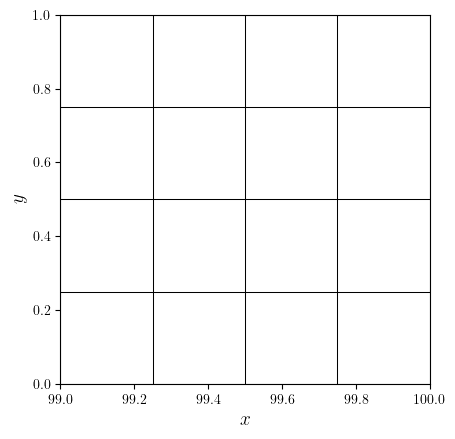

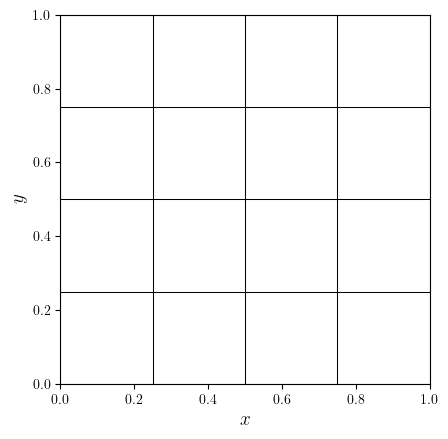

: 

In [ ]:
plot_mesh(original)
plot_mesh(copied)